
<h1 style="text-align: center;">CIÊNCIA DE DADOS</h1>
<h1 style="text-align: center;">Roteiro de Atividade Prática</h1>
<br>
<br>

Nome: ______________________________________________________________________________________      

Turma: ______________


**Componente:** Inteligência Artificial 
<br>
**Unidade Curricular:** Redes Neurais
<br>
**Tema da Semana:** Redes Neurais Recorrentes (RNNs)
<br>


# Aula 2: RNNs

## Tarefa

- Se as bibliotecas não tiverem instaladas, instale-as.

- Acompanhe as instruções.

- Execute o código.

- Responda as perguntas e conclua a atividade


### Código

### Instalação das dependência do tensorflow

In [1]:
#!pip install --upgrade pip setuptools wheel

In [2]:
#!pip install tensorflow

In [3]:
#!conda install anaconda::tensorflow

In [4]:
#!pip install numpy pandas matplotlib

### Imports de dependências

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from numpy.lib.stride_tricks import sliding_window_view
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.initializers import GlorotUniform

2024-10-13 15:30:18.126470: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-10-13 15:30:18.129097: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-10-13 15:30:18.137379: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-13 15:30:18.151057: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-13 15:30:18.155137: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-13 15:30:18.165162: I tensorflow/core/platform/cpu_feature_gu

### Configurações

In [6]:
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

### Leitura dos dados

In [7]:
df = pd.read_csv('heart-rate-time-series.csv', names=['Data'])

In [8]:
# Número total de pontos no tempo (quantidade total de dados na série temporal)
N = df.shape[0] 

# Ponto no tempo para separar os dados de treino e teste (usando 30% dos dados para teste)
Tp = int( N - (N * 0.30)) 

### Apresentação dos dados

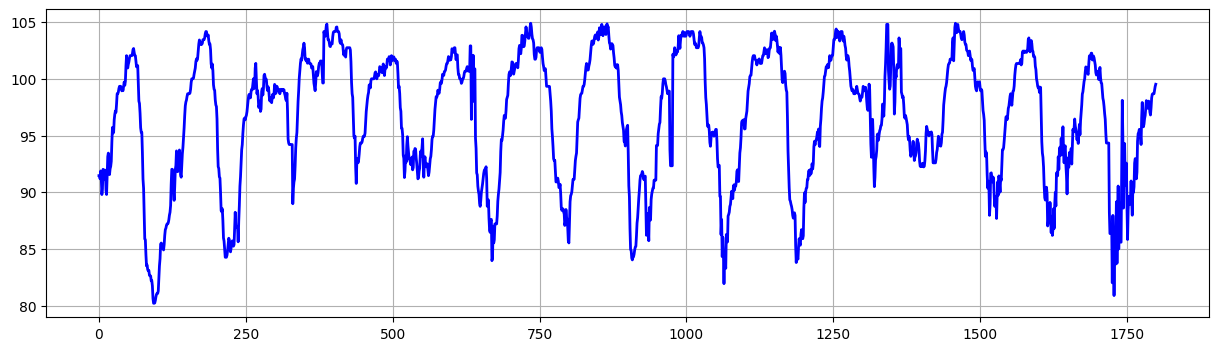

In [9]:
plt.figure(figsize=(15,4))
plt.plot(df,c='blue',linewidth=2)
plt.grid(True)
plt.show()

### Separaçao em dos dados em Treino e Teste

In [10]:
values=df.values
train,test = values[0:Tp,:], values[Tp:N,:]

### Apresentação dos dados de Treino e Teste

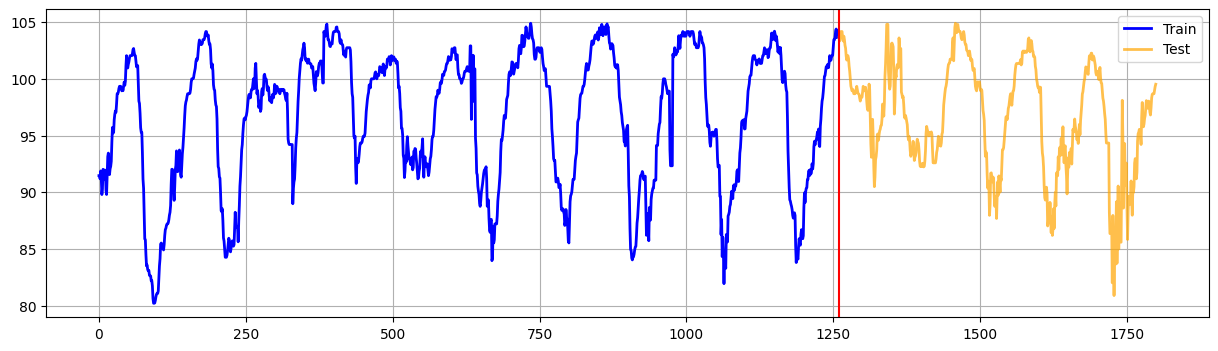

In [11]:
index = df.index.values
plt.figure(figsize=(15,4))
plt.plot(index[0:Tp],train,c='blue', linewidth=2)
plt.plot(index[Tp:N],test,c='orange',alpha=0.7, linewidth=2)
plt.legend(['Train','Test'])
plt.axvline(df.index[Tp], c="r")
plt.grid(True)
plt.show()

### Ajuste dos dados para matrix com 4 ponto no tempo

In [12]:
steps = 4

test = np.append(test, np.repeat(test[-1,], steps))
train = np.append(train, np.repeat(train[-1,], steps))

In [13]:
def generate_time_steps(data, step):
    X = sliding_window_view(data, window_shape=step)[:-1]
    Y = data[step:]
    return X, Y

In [14]:
# Converte os dados de treino e teste
X_train, y_train = generate_time_steps(train, steps)
X_test, y_test = generate_time_steps(test, steps)

In [15]:
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

### Criação o modelo

In [16]:
model = Sequential()

# Unidades recorrentes (SimpleRNN): A camada SimpleRNN é responsável por processar cada elemento da sequência de dados. 
# Cada unidade recebe uma entrada e o estado oculto da etapa anterior.
# O estado oculto é mantido entre as unidades recorrentes e carrega informações anteriores da sequência, 
# permitindo à rede aprender dependências temporais.
model.add(SimpleRNN(units=15, input_shape=(1, steps), activation="relu",
                    kernel_initializer=GlorotUniform(seed=42)))
model.add(Dropout(0.09, seed=SEED))
model.add(Dense(32, activation="relu"))
model.add(Dense(1))

I0000 00:00:1728844219.641450  239283 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-10-13 15:30:19.641971: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2343] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
/home/janes/dev/projects/seduc/ano2/seduc/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__

In [17]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error',  metrics=['mse'])

### Perguntas e Conclusão

##### Quantas Unidades recorrentes foram utilizadas?
##### Qual o algoritmo de otimização utilizado?
##### Qual a loss fuction utilizada?